# Fee drag mitigation search under a 10 BPS vault exit fee

Based on `56-opt-cadence-hold-concentration-breadth.ipynb`. NB56 searched cadence, hold,
concentration and breadth with no trading cost. This variant charges a **10 BPS fee on every vault
sell** and searches only the three levers that can reduce it.

Concentration is pinned at **35%** and breadth at **6 vaults** as instructed; every other parameter
is the NB36/NB53 value. Searched: `rebalance_every_n_days` (1-7), `minimum_hold_days` (1-7) and
`sell_rebalance_min_threshold_usd` (5 / 25 / 50 / 125 / 250 USD, i.e. 0.02% to 1.0% of the $25,000
bankroll). The Gaussian Process made 108 evaluations covering **93 unique scored combinations** of
the 245 possible; 12 evaluations were repeats and 3 crashed.

Window is 2026-01-01 to 2026-07-10 (190 days), inherited from NB56, on the hl-min-1000 dataset.

## Why these three levers

`62-backtest-nb36-exit-fee-stress-0-10-20bps.ipynb` measured the cost as a pure linear tax on
redemption turnover - identical positions at 0, 10 and 20 BPS, about -0.33 pp of CAGR per BPS.
Decomposing that turnover: 99 exits carried 62.3% of sell volume, 543 trims carried 37.7%. The
softband attacks the trims; cadence and hold attack the exits.

Calmar is the objective because two of the three levers trade fee savings against tail risk.

## Key new insights and what did we learn from this experiment?

### Cadence 2 is the answer, and the gain is real but smaller than a naive read suggests

Isolating cadence at a **non-binding hold**, so the hold confound is removed:

| `rebalance_every_n_days` | Configs | CAGR | Max DD | Calmar |
|---:|---:|---:|---:|---:|
| 1 (daily) | 1 | 17.92% | -7.61% | 2.35 |
| **2** | 10 | **33.64%** | **-6.62%** | **5.08** |
| 3 | 3 | 12.59% | -7.57% | 1.66 |
| 4 | 8 | 13.64% | -8.50% | 1.60 |
| 5 | 7 | 21.15% | -9.88% | 2.14 |
| 6 | 8 | 11.30% | -7.68% | 1.47 |
| 7 | 5 | -4.88% | -11.42% | -0.43 |

**Every-other-day rebalancing roughly doubles Calmar against daily (5.08 versus 2.35) and improves
drawdown at the same time.** It is a large, one-parameter win.

Cadence is genuinely non-monotonic: 2 is the peak, 3-6 are worse than daily on Calmar, and 7 turns
the strategy negative (-4.88% CAGR, -11.42% drawdown) as momentum-gate exits arrive too late. There
is no "slower is better" trend to extrapolate - **only cadence 2 works.**

### `minimum_hold_days` is inert below the cadence, so most of its apparent effect is an artefact

A position is only re-evaluated on rebalance cycles, so its age at every decision point is an exact
multiple of `rebalance_every_n_days`. The effective hold is `ceil(hold / cadence) * cadence`, and
any configuration with `minimum_hold_days <= rebalance_every_n_days` is **byte-identical** to
`minimum_hold_days = 1`. At the winning cadence 2, holds 1 and 2 are literally the same backtest -
visible in the results table as pairs with identical trade counts and metrics.

The notebook now reports `effective_hold_days` so this cannot be misread as a plateau.

### The softband is a small, clean, monotone win - not noise

At the winning cadence, with hold non-binding, widening the sell-side band monotonically reduces
trading and slightly improves return:

| `sell_rebalance_min_threshold_usd` | Trades | CAGR | Max DD | Calmar |
|---:|---:|---:|---:|---:|
| 5 (release default, 0.02% of capital) | 514 | 33.45% | -6.61% | 5.060 |
| 25 | 495 | 33.51% | -6.62% | 5.064 |
| 50 | 480 | 33.53% | -6.62% | 5.068 |
| 125 | 427 | 33.68% | -6.61% | 5.095 |
| **250** (1.0% of capital) | **402** | **34.03%** | **-6.63%** | **5.130** |

$5 to $250 removes 112 trades (-22%) and adds 0.58 pp of CAGR at unchanged drawdown. The effect is
small but strictly ordered across all five levels, which is what a real cost saving looks like.
The **caveat** is that $250 is also where all three crashes occurred.

### Turnover, measured within this sweep

| | Winner (cadence 2, hold 2, $250) | Best daily cadence (cadence 1, hold 1, $125) |
|---|---:|---:|
| Redemption turnover | 12.5x capital | 16.2x capital |
| Annualised | 24.0x/yr | 31.1x/yr |

Cadence 2 cuts turnover by **23%**, not the "more than half" claimed in the previous version of
this heading - that figure compared against NB62's 27.9x, which is a 344-day window at 50%
concentration with no cadence logic, and is not comparable.

## Summary of results

Best configuration: **`rebalance_every_n_days=2`, `minimum_hold_days=1 or 2` (identical),
`sell_rebalance_min_threshold_usd=250`**.

| Metric | Winner | Best daily-cadence configuration |
|---|---:|---:|
| CAGR | **34.03%** | 17.92% |
| Max drawdown | **-6.63%** | -7.61% |
| Sharpe | 1.71 | - |
| Sortino | 2.50 | - |
| Calmar | **5.130** | 2.35 |
| Trades | 402 | - |
| Redemption turnover | 12.5x | 16.2x |

## Robustness of results

- **Metrics are recomputed from each result's return series, not read from `GridSearchResult`.**
  The accessors return quantstats metrics built with `.round(2)` on fractions, so CAGR and drawdown
  land on a **one percentage point grid** - every stored value in this sweep was an exact multiple
  of 0.01. That quantisation manufactures ties: the top five configurations all read "Calmar 4.86"
  from the rounded metrics while their true Calmars are 5.130, 5.095, 5.068, 5.064 and 5.060. An
  earlier version of this notebook reported that tie as a stability signal; it was rounding.
  **`optimise_calmar` ranks on the same rounded metrics**, so the search itself explored using a
  coarse objective - a reason to treat the ranking as a shortlist rather than a precise ordering.
- **The confound-free cadence-1 cell rests on a single configuration.** Requiring a non-binding hold
  at cadence 1 admits only `minimum_hold_days=1`, and the GP evaluated that once. The 17.92% is
  therefore a point estimate, not a mean. The unrestricted cadence-1 marginal (9 configs) reads
  3.02% CAGR, but its mean effective hold is 5.1 against 3.7 at cadence 2, and long holds are
  independently bad - so that number overstates the gap. The truth is between them, and the
  direction is not in doubt.
- **Duplicates removed.** The GP re-evaluated 12 points; scoring them twice would have weighted the
  marginals toward whatever it liked. 93 unique configurations remain.
- **Three configurations crashed** with `BacktestExecutionFailed`, all at `sell_rebalance_min_threshold_usd=250`
  with cadence 1-2 and holds 6-7. `ignore_wallet_errors=True` converts these into placeholder
  results whose equity curves are indexed at 1970-01-01; they are now excluded from both the results
  table and the equity curve chart, which they previously stretched across 56 years of x axis.
- **The fee is verified on more than one configuration**: median implied fee exactly 0.100% against
  a configured 0.100% on both the winner and the daily-cadence reference. Only ~51% of individual
  sells land within 1 BPS, because Hypercore partial reductions execute at the position's marked
  price rather than the current close - NB62 established that this dispersion is present identically
  in a 0 BPS control, so it is mark-versus-close noise, not fee leakage. It is lower here than
  NB62's ~70% because a 2-day cadence prices trims off staler marks.
- **The grid search cache key covers only the searched parameters**, not the fee, the pinned
  concentration or `decide_trades`. All 96 cache entries were written in one batch during the
  first run, so no stale reuse occurred here - but re-running this notebook id after changing the
  fee would silently serve the old results. Clear
  `~/.cache/tradingstrategy/grid-search/63-opt-fee-drag-mitigation-10bps/` when changing anything
  unsearched.
- One in-sample window of 190 days in a single regime. **Not tested: whether cadence 2 still wins
  at 0 BPS.** Part of this result may be the fee reshaping the landscape rather than cadence 2
  being universally better; the same grid at zero fee would settle it.

## What to do about it

1. **Move the release candidate to 2-day rebalancing.** One parameter, roughly doubles Calmar,
   improves drawdown, cuts turnover 23%.
2. **Widen the sell-side softband** from $5 toward $125-250 (0.5-1.0% of capital). Small but
   strictly ordered gain, and it cannot change which vaults are held. Prefer $125 over $250 until
   the crashes at $250 are understood.
3. **Leave `minimum_hold_days` at 1.** At cadence 2 anything up to 2 is identical, and higher values
   only hurt.
4. **Do not go past cadence 3.** The gate needs to fire promptly; cadence 7 is loss-making.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Start from the NB36 / NB53 release-candidate configuration.
- **Pinned**: `max_concentration_pct = 0.35`, `max_assets_in_portfolio = 6`.
- **Searched**: `rebalance_every_n_days` and `minimum_hold_days` over 1-7 days, and
  `sell_rebalance_min_threshold_usd` over 5 / 25 / 50 / 125 / 250 USD - that is 0.02%, 0.1%,
  0.2%, 0.5% and 1.0% of the $25,000 bankroll.
- A 10 BPS vault exit fee is charged on every sell, applied to the trading universe below.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from skopt.space import Categorical

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '63-opt-fee-drag-mitigation-10bps'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: The engine still steps daily. The traded cadence is imposed inside
    #: :py:func:`decide_trades` via :py:attr:`rebalance_every_n_days` so indicators and the
    #: momentum gate keep their daily resolution regardless of the cadence under test.
    cycle_duration = CycleDuration.cycle_1d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Pinned for this variant: the NB35/NB36 six-vault basket. Breadth is not a fee lever,
    #: and holding it fixed keeps the search on the three turnover parameters.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Pinned for this variant at the NB53 ceiling, as instructed.
    max_concentration_pct = 0.35
    #: Fixed for this variant: the NB36/NB53 release-candidate per-vault TVL cap.
    per_position_cap_of_pool_pct = 0.15
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Searched: act only on every Nth daily strategy cycle. ``1`` reproduces NB54's
    #: unconditional daily rebalance; higher values leave the basket untouched in between,
    #: which also defers deploying new cash and defers momentum-gate exits.
    rebalance_every_n_days = Categorical([1, 2, 3, 4, 5, 6, 7])
    #: Searched: keep an eligible incumbent's basket slot until the position is at least
    #: this many days old, even when composite ranking has pushed it out of the top
    #: :py:attr:`max_assets_in_portfolio`. Vaults dropped by the momentum gate or by the
    #: quarantine list are not protected, so this suppresses rank-drift churn only.
    #: ``1`` is effectively no hold at a daily cadence.
    minimum_hold_days = Categorical([1, 2, 3, 4, 5, 6, 7])

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Searched: sell-side softband in USD. The release default floors at 5 USD, which is
    #: 0.02% of the bankroll, so nearly every weight drift triggers a trim; NB62 measured
    #: 543 such trims worth $263k. The ladder spans 0.02% to 1.0% of initial cash.
    #: Searched directly in USD because a fraction-of-cash parameter cannot be multiplied
    #: out at class creation time while it is a search dimension.
    sell_rebalance_min_threshold_usd = Categorical([5.0, 25.0, 50.0, 125.0, 250.0])

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    inverse_vol_window = 60

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 25_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Vault exit fee charged on every Hypercore redemption. Applied to the trading
    #: universe as a sell-side token tax, see the universe cell.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-10 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,0.5,float
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

ARCHIVE = Path('/Users/moo/code/hl-vault-cached-backup')
DATASET_ROOT = Path('/tmp/nb63-hl-min-1000')


def prepare_dataset_root() -> Path:
    """Materialise the hl-min-1000 dataset in an isolated cache directory.

    Leaves the shared `~/.cache/tradingstrategy` untouched. The loader skips its HTTP HEAD
    check when the cached file is under 24h old, so the copies are refreshed only as they
    approach that bound - touching every run would change the indicator cache fingerprint
    and force a full recalculation.
    """
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    for src_path, dst_path in [
        (ARCHIVE / 'hl-min-1000' / 'vault-price-history.parquet', DATASET_ROOT / 'vault-price-history.parquet'),
        (ARCHIVE / 'hl-min-1000' / 'vault-universe.json', DATASET_ROOT / 'vault-universe.json'),
    ]:
        assert src_path.exists(), f'Dataset missing: {src_path}'
        if not dst_path.exists() or dst_path.stat().st_size != src_path.stat().st_size:
            shutil.copy2(src_path, dst_path)
        if time.time() - dst_path.stat().st_mtime > 12 * 3600:
            dst_path.touch()
    return DATASET_ROOT


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        vault_history_download_root=str(prepare_dataset_root()),
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_fee(universe, fee) -> int:
    """Charge a flat exit fee on the sell side of every vault pair.

    The backtest pricing model resolves a trade fee as ``pair.fee + directional token tax``.
    Vault pairs carry ``pair.fee == 0``, so a ``sell_tax`` on the vault share token makes the
    sell price ``share price x (1 - fee)`` while deposits stay at NAV.

    Mutating the universe here covers every optimiser combination: the mutated pair objects
    live in :py:attr:`TradingStrategyUniverse.pair_cache`, which is pickled to the worker
    processes along with the rest of the universe.
    """
    assert 0 <= fee < 0.10, f"Exit fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS exit fee to {fee_applied} vault pairs')


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 7aa6c710
Loaded 326 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur7aa6c710)


Loaded 326 vaults from remote vault metadata, source vaults count: 326


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 60.32it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,30 days 00:00:00,0.00,"12,784",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,30 days 00:00:00,0.00,"28,035",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,30 days 00:00:00,0.00,"65,250",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,30 days 00:00:00,0.00,"31,126",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,30 days 00:00:00,0.00,107,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,30 days 00:00:00,0.00,"14,927",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,30 days 00:00:00,0.00,"150,636",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,30 days 00:00:00,0.00,579,29 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,30 days 00:00:00,0.00,"7,422",29 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS exit fee to 326 vault pairs


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)


We have 10 indicators:


,Order,Source,Parameters,Dependencies
Name,,,,
cagr_score,1,close_price,cagr_lookback_days,
inverse_vol,1,close_price,inverse_vol_window,
return_gate,1,close_price,gate_lookback_days,
sharpe_score,1,close_price,sharpe_lookback_days,
trading_availability_criteria,1,strategy_universe,,
tvl,1,tvl,,
cagr_sharpe_weight,2,dependencies_only_per_pair,cagr_lookback_days<br> cagr_weight<br> sharpe_...,cagr_score<br> sharpe_score
tvl_inclusion_criteria,2,dependencies_only_universe,min_tvl_usd,tvl
inclusion_criteria,3,strategy_universe,min_tvl_usd,tvl_inclusion_criteria<br> trading_availabilit...


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_days = int(parameters.rebalance_every_n_days)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # Rebalance cadence. `input.cycle` is 1-based, so cycle #1 always rebalances and the
    # portfolio is then left completely untouched for the next `rebalance_every_n_days - 1`
    # daily cycles: no new cash deployed, no momentum-gate exits, no reweighting.
    if (input.cycle - 1) % rebalance_every_n_days != 0:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    weight_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        weight_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Rebalance every N days: {rebalance_every_n_days}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Optimiser

- Run optimiser

In [8]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning,
)

import logging
from tradeexecutor.backtest.optimiser import perform_optimisation
from tradeexecutor.backtest.optimiser import prepare_optimiser_parameters
from tradeexecutor.backtest.optimiser import MinTradeCountFilter
from tradeexecutor.backtest.optimiser_functions import optimise_sharpe, optimise_calmar

# How many Gaussian Process iterations we do.
# The factorial space is 7 x 7 x 5 = 245 combinations, so 18 iterations at batch size 6
# samples roughly 108 of them. Raise to 28 once the notebook is confirmed working if the
# Calmar plateau looks under-determined.
iterations = 18

# What do we optimise for
# Tune the holding period for drawdown control: Calmar = CAGR / |max drawdown|.
search_func = optimise_calmar
# search_func = optimise_sharpe

optimiser_result = perform_optimisation(
    iterations=iterations,
    search_func=search_func,
    decide_trades=decide_trades,
    strategy_universe=strategy_universe,
    parameters=prepare_optimiser_parameters(Parameters),  # Handle scikit-optimise search space
    create_indicators=indicators.create_indicators,
    # A 7-day cadence leaves only ~27 rebalance cycles in the 2026 window, so the
    # original 50-trade floor would have filtered out exactly the slow-cadence
    # configurations this notebook exists to measure.
    result_filter=MinTradeCountFilter(20),
    timeout=70*60,    
    batch_size=6,
    # We are searching wacky parameter combinations and
    # some of them lead to buggy strategies,
    # by setting ignore_wallet_errors we just zero out buggy
    # strategies instead of crashing with an exception
    ignore_wallet_errors=True,  
    # Uncomment for diagnostics
    # log_level=logging.INFO,
    # max_workers=1,
)

print(f"Optimise completed, optimiser searched {optimiser_result.get_combination_count()} combinations, with {optimiser_result.get_cached_count()} results read directly from cache. and {optimiser_result.get_filtered_count()} filtered results.")
print("Backtests failed with exception:", optimiser_result.get_failed_count())

Optimiser search result cache is /Users/moo/.cache/tradingstrategy/grid-search/63-opt-fee-drag-mitigation-10bps
Indicator cache is /Users/moo/.cache/indicators


Optimise completed, optimiser searched 108 combinations, with 108 results read directly from cache. and 0 filtered results.
Backtests failed with exception: 3


# Results

- Show the top results of all optimiser iterations in a single table

In [9]:
import math

from tradeexecutor.statistics.key_metric import (
    calculate_cagr, calculate_max_drawdown, calculate_sharpe, calculate_sortino,
)

filtered = [r for r in optimiser_result.results if r.filtered]
print(f"Filtering out {len(filtered)} results")

# Metrics are recomputed from each result's own return series rather than read from
# `GridSearchResult.get_cagr()` / `get_max_drawdown()`.
#
# Those accessors read `self.metrics`, which quantstats builds with `.round(2)`. Because the
# values are fractions, CAGR and max drawdown land on a **one percentage point grid**: every
# stored CAGR in this sweep is an exact multiple of 0.01. That quantisation manufactures ties -
# the top five configurations all read "Calmar 4.86" from the rounded metrics while their true
# Calmars are 5.06, 5.10, 5.06, 5.13 and 5.07. Note `optimise_calmar`, the search objective,
# reads the same rounded metrics, so the GP itself ranked on a coarse signal.
rows = []
failures = []
for r in optimiser_result.results:
    if r.filtered:
        continue
    result = r.result
    if result.exception is not None:
        # `ignore_wallet_errors=True` converts a crashed backtest into a placeholder result whose
        # equity curve is indexed at 1970-01-01. Record it rather than scoring it.
        failures.append({
            **{param.name: param.value for param in result.combination.searchable_parameters},
            "exception": type(result.exception).__name__,
        })
        continue

    returns = result.returns.dropna()
    if not len(returns):
        continue

    params = {param.name: param.value for param in result.combination.searchable_parameters}
    cagr = float(calculate_cagr(returns))
    max_dd = float(calculate_max_drawdown(returns))
    rows.append({
        **params,
        "Trades": result.get_trade_count(),
        "CAGR": cagr,
        "Max DD": max_dd,
        "Sharpe": float(calculate_sharpe(returns, periods=365)),
        "Sortino": float(calculate_sortino(returns, periods=365)),
        "Calmar": cagr / abs(max_dd) if abs(max_dd) > 0 else float("nan"),
    })

if failures:
    print(f"{len(failures)} configuration(s) crashed and were excluded:")
    display(pd.DataFrame(failures))

parameter_names_raw = [p.name for p in optimiser_result.results[0].result.combination.searchable_parameters]
raw = pd.DataFrame(rows)

# `minimum_hold_days` only binds when it exceeds the cadence: a position is re-evaluated on
# rebalance cycles only, so its age at every decision point is an exact multiple of
# `rebalance_every_n_days`. The effective hold is therefore ceil(hold / cadence) * cadence, and
# any configuration with hold <= cadence is byte-identical to hold = 1 at the same cadence.
raw["effective_hold_days"] = [
    math.ceil(h / c) * c for h, c in zip(raw["minimum_hold_days"], raw["rebalance_every_n_days"])
]

# The Gaussian Process re-evaluates promising points, so the same combination can appear more
# than once. Duplicates would weight the per-lever means towards whatever the GP liked.
duplicates = len(raw) - len(raw.drop_duplicates(subset=parameter_names_raw))
if duplicates:
    print(f"Dropping {duplicates} duplicate evaluation(s) of combinations the optimiser revisited")
raw = raw.drop_duplicates(subset=parameter_names_raw, keep="first")

df = raw.set_index(parameter_names_raw).sort_values("Calmar", ascending=False)

degenerate = int(df["Calmar"].isna().sum())
if degenerate:
    print(f"Dropping a further {degenerate} configuration(s) with an undefined Calmar")
    df = df[df["Calmar"].notna()]

print(f"Showing {len(df)} unique configurations, best Calmar {df['Calmar'].iloc[0]:.3f}")

display(
    df.head(25).reset_index().style.format({
        "CAGR": "{:.2%}", "Max DD": "{:.2%}", "Sharpe": "{:.2f}",
        "Sortino": "{:.2f}", "Calmar": "{:.3f}", "Trades": "{:.0f}",
        "effective_hold_days": "{:.0f}",
    }).background_gradient(subset=["Calmar"], cmap="RdYlGn")
    .set_caption("Top 25 unique configurations by Calmar, 10 BPS exit fee (metrics recomputed from returns)")
)


Filtering out 0 results


3 configuration(s) crashed and were excluded:


,minimum_hold_days,rebalance_every_n_days,sell_rebalance_min_threshold_usd,exception
0,7,2,250.0,BacktestExecutionFailed
1,6,1,250.0,BacktestExecutionFailed
2,7,1,250.0,BacktestExecutionFailed


Dropping 12 duplicate evaluation(s) of combinations the optimiser revisited
Showing 93 unique configurations, best Calmar 5.130


,minimum_hold_days,rebalance_every_n_days,sell_rebalance_min_threshold_usd,Trades,CAGR,Max DD,Sharpe,Sortino,Calmar,effective_hold_days
0,2,2,250.000000,402,34.03%,-6.63%,1.71,2.50,5.130,2
1,1,2,250.000000,402,34.03%,-6.63%,1.71,2.50,5.130,2
2,1,2,125.000000,427,33.68%,-6.61%,1.69,2.48,5.095,2
3,2,2,125.000000,427,33.68%,-6.61%,1.69,2.48,5.095,2
4,1,2,50.000000,480,33.53%,-6.62%,1.69,2.47,5.068,2
5,2,2,50.000000,480,33.53%,-6.62%,1.69,2.47,5.068,2
6,2,2,25.000000,495,33.51%,-6.62%,1.69,2.47,5.064,2
7,1,2,25.000000,495,33.51%,-6.62%,1.69,2.47,5.064,2
8,1,2,5.000000,514,33.45%,-6.61%,1.69,2.47,5.060,2
9,2,2,5.000000,514,33.45%,-6.61%,1.69,2.47,5.060,2


## Did the fee actually apply, and what did each lever do to turnover?

The optimiser pickles the universe to worker processes, so the first check is that the sell-side
tax survived that trip. The measurement compares each vault sell's executed price against the
vault's own daily close, which is independent of the two Hypercore sell paths.

Then, the point of the whole notebook: redemption volume and fees paid for the best configuration
versus the release-candidate baseline (daily cadence, no hold, $5 softband).

In [10]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        if candles is None or not len(candles):
            return float("nan")
        closes = candles.set_index("timestamp")["close"].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float("nan")


def turnover_report(grid_result, label: str) -> dict:
    """Sell-side turnover, fee paid and implied fee for one grid search result."""
    run_state = grid_result.hydrate_state()
    fee = Parameters.vault_redemption_fee
    exits = trims = 0
    exit_volume = trim_volume = 0.0
    implied = []
    for t in run_state.portfolio.get_all_trades():
        if not t.pair.is_vault() or not t.is_sell() or not t.is_success():
            continue
        value = abs(float(t.get_value() or 0.0))
        if t.closing:
            exits += 1
            exit_volume += value
        else:
            trims += 1
            trim_volume += value
        share_price = get_vault_share_price(t.pair, t.opened_at)
        if share_price == share_price:
            implied.append(1.0 - t.planned_price / share_price)
    volume = exit_volume + trim_volume
    implied_series = pd.Series(implied)
    days = (Parameters.backtest_end - Parameters.backtest_start).days
    return {
        "Configuration": label,
        "Vault sells": exits + trims,
        "Exits": exits,
        "Trims": trims,
        "Exit volume": exit_volume,
        "Trim volume": trim_volume,
        "Redemption volume": volume,
        "Turnover x capital": volume / Parameters.initial_cash,
        "Turnover x capital, annualised": volume / Parameters.initial_cash * 365 / days,
        "Fee paid": volume * fee / (1.0 - fee),
        "Median implied fee": float(implied_series.median()) if len(implied_series) else float("nan"),
        "Within 1 BPS of target": float((implied_series.sub(fee).abs() <= 0.0001).mean()) if len(implied_series) else float("nan"),
    }


def find_result(**params):
    """Locate the GridSearchResult for an exact parameter combination."""
    for r in optimiser_result.results:
        if r.filtered or r.result.exception is not None:
            continue
        combo = {p.name: p.value for p in r.result.combination.searchable_parameters}
        if all(combo.get(k) == v for k, v in params.items()):
            return r.result
    return None


# The winner, plus the best daily-cadence configuration **from this same sweep** as the
# reference. NB62's 27.9x turnover is not a valid comparison: it runs a 344-day window against
# this notebook's 190 days, at 50% concentration and with no cadence logic at all.
best_params = dict(zip(df.index.names, df.index[0]))
best_result = find_result(**best_params)

daily = df[df.index.get_level_values("rebalance_every_n_days") == 1]
reports = [turnover_report(best_result, f"Winner: {best_params}")]
if len(daily):
    daily_params = dict(zip(df.index.names, daily.index[0]))
    daily_result = find_result(**daily_params)
    if daily_result is not None:
        reports.append(turnover_report(daily_result, f"Best daily cadence: {daily_params}"))
else:
    print("No daily-cadence configuration survived, so no in-sweep turnover reference is available")

turnover_df = pd.DataFrame(reports).set_index("Configuration")
display(turnover_df.T.style.format("{:,.4g}").set_caption(
    "Turnover and fees: winner versus the best daily-cadence configuration in this sweep"))

for label, row in turnover_df.iterrows():
    median_fee = row["Median implied fee"]
    within = row["Within 1 BPS of target"]
    target = Parameters.vault_redemption_fee
    print(f"{label}: median implied fee {median_fee:.3%} (target {target:.3%}), "
          f"{within:.1%} of sells within 1 BPS, turnover {row['Turnover x capital']:.1f}x "
          f"({row['Turnover x capital, annualised']:.1f}x annualised)")
    assert abs(median_fee - target) < 1e-5, (
        f"Exit fee did not survive the optimiser for {label}: median implied {median_fee:.4%}"
    )
print("Fee verified on every configuration inspected.")

# How the searched levers move outcomes. Deduplicated above, but the Gaussian Process still
# samples unevenly, so these marginals are confounded: cadence 1 was mostly explored with long
# holds (which are independently bad) and cadence 2 with short ones. The fixed-hold slice below
# is the one that isolates cadence.
sweep = df.reset_index()
for lever in ("sell_rebalance_min_threshold_usd", "rebalance_every_n_days", "minimum_hold_days", "effective_hold_days"):
    grouped = sweep.groupby(lever).agg(
        configs=("CAGR", "size"), mean_hold=("effective_hold_days", "mean"),
        cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "calmar": "{:.2f}", "mean_hold": "{:.1f}",
    }).set_caption(f"Mean outcome by {lever} (unique configurations; mean_hold exposes the sampling confound)"))

# Cadence isolated at the shortest effective hold, where the GP sampled every cadence.
short_hold = sweep[sweep.effective_hold_days <= sweep.rebalance_every_n_days]
if len(short_hold):
    grouped = short_hold.groupby("rebalance_every_n_days").agg(
        configs=("CAGR", "size"), cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({"cagr": "{:.2%}", "max_dd": "{:.2%}", "calmar": "{:.2f}"})
            .set_caption("Cadence marginal restricted to a non-binding hold - the confound-free comparison"))


Configuration,"Winner: {'minimum_hold_days': np.int64(2), 'rebalance_every_n_days': np.int64(2), 'sell_rebalance_min_threshold_usd': np.float64(250.0)}","Best daily cadence: {'minimum_hold_days': np.int64(1), 'rebalance_every_n_days': np.int64(1), 'sell_rebalance_min_threshold_usd': np.float64(125.0)}"
Vault sells,146,231
Exits,64,77
Trims,82,154
Exit volume,2.296e+05,2.932e+05
Trim volume,8.275e+04,1.119e+05
Redemption volume,3.124e+05,4.05e+05
Turnover x capital,12.49,16.2
"Turnover x capital, annualised",24,31.12
Fee paid,312.7,405.4
Median implied fee,0.001,0.001


Winner: {'minimum_hold_days': np.int64(2), 'rebalance_every_n_days': np.int64(2), 'sell_rebalance_min_threshold_usd': np.float64(250.0)}: median implied fee 0.100% (target 0.100%), 51.4% of sells within 1 BPS, turnover 12.5x (24.0x annualised)
Best daily cadence: {'minimum_hold_days': np.int64(1), 'rebalance_every_n_days': np.int64(1), 'sell_rebalance_min_threshold_usd': np.float64(125.0)}: median implied fee 0.100% (target 0.100%), 52.4% of sells within 1 BPS, turnover 16.2x (31.1x annualised)
Fee verified on every configuration inspected.


,configs,mean_hold,cagr,max_dd,calmar
sell_rebalance_min_threshold_usd,,,,,
5.000000,18,6.3,16.04%,-8.01%,2.18
25.000000,18,6.1,16.29%,-9.17%,2.07
50.000000,17,6.3,15.71%,-8.01%,2.14
125.000000,22,5.8,16.02%,-7.93%,2.14
250.000000,18,5.9,15.65%,-7.97%,2.17


,configs,mean_hold,cagr,max_dd,calmar
rebalance_every_n_days,,,,,
1,9,5.1,3.02%,-9.42%,0.51
2,19,3.7,25.03%,-7.28%,3.68
3,16,6.2,17.87%,-6.70%,2.70
4,18,6.2,12.86%,-8.53%,1.51
5,13,7.3,21.38%,-9.13%,2.36
6,13,8.3,16.11%,-7.98%,1.99
7,5,7.0,-4.88%,-11.42%,-0.43


,configs,mean_hold,cagr,max_dd,calmar
minimum_hold_days,,,,,
1,14,3.4,20.74%,-8.10%,2.83
2,10,2.7,24.24%,-7.43%,3.43
3,6,5.0,14.65%,-8.54%,1.93
4,13,5.1,15.91%,-7.81%,2.08
5,9,6.1,10.68%,-9.23%,1.48
6,16,6.9,13.45%,-7.82%,1.85
7,25,9.2,13.77%,-8.60%,1.74


,configs,mean_hold,cagr,max_dd,calmar
effective_hold_days,,,,,
1,1,1.0,17.92%,-7.61%,2.35
2,11,2.0,31.84%,-6.71%,4.79
3,3,3.0,12.59%,-7.57%,1.66
4,13,4.0,16.25%,-7.93%,2.12
5,8,5.0,17.44%,-10.68%,1.81
6,21,6.0,14.59%,-7.18%,2.10
7,9,7.0,-4.10%,-10.60%,-0.38
8,12,8.0,10.55%,-8.80%,1.23
9,4,9.0,20.32%,-6.81%,2.98


,configs,cagr,max_dd,calmar
rebalance_every_n_days,,,,
1,1,17.92%,-7.61%,2.35
2,10,33.64%,-6.62%,5.08
3,3,12.59%,-7.57%,1.66
4,8,13.64%,-8.50%,1.60
5,7,21.15%,-9.88%,2.14
6,8,11.30%,-7.68%,1.47
7,5,-4.88%,-11.42%,-0.43


## Search stability check

Do the top configurations agree on their parameters, and how tight is the Calmar plateau? Read alongside the heatmaps, cluster analysis and parallel-coordinates plots below.

In [11]:
# Numeric stability: parameter consensus across the top-Calmar configs.
stab = df.reset_index().copy()
if 'Calmar' not in stab.columns:
    stab['Calmar'] = stab['CAGR'] / stab['Max DD'].abs().replace(0, float('nan'))
stab = stab.sort_values('Calmar', ascending=False)
param_cols = list(df.index.names)
TOPN = 15
top = stab.head(TOPN)

print(f"Parameter consensus across the top {TOPN} configs by Calmar:")
rows = []
for pc in param_cols:
    vc = top[pc].value_counts(normalize=True)
    rows.append({'parameter': pc, 'mode': vc.index[0], 'mode_share': round(float(vc.iloc[0]), 2), 'distinct_in_top': int(top[pc].nunique())})
display(pd.DataFrame(rows))

print(f"Calmar in top {TOPN}: {top['Calmar'].min():.2f} - {top['Calmar'].max():.2f}   (all {len(stab)}: {stab['Calmar'].min():.2f} - {stab['Calmar'].max():.2f})")
print("A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.")


Parameter consensus across the top 15 configs by Calmar:


,parameter,mode,mode_share,distinct_in_top
0,minimum_hold_days,2.0,0.33,5
1,rebalance_every_n_days,2.0,0.93,2
2,sell_rebalance_min_threshold_usd,125.0,0.27,5


Calmar in top 15: 3.00 - 5.13   (all 93: -0.53 - 5.13)
A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.


## Equity curves

- Visualise equity curves of all grid search results in a single chart

Excluding 3 backtest(s) that failed with an exception from the equity curve chart


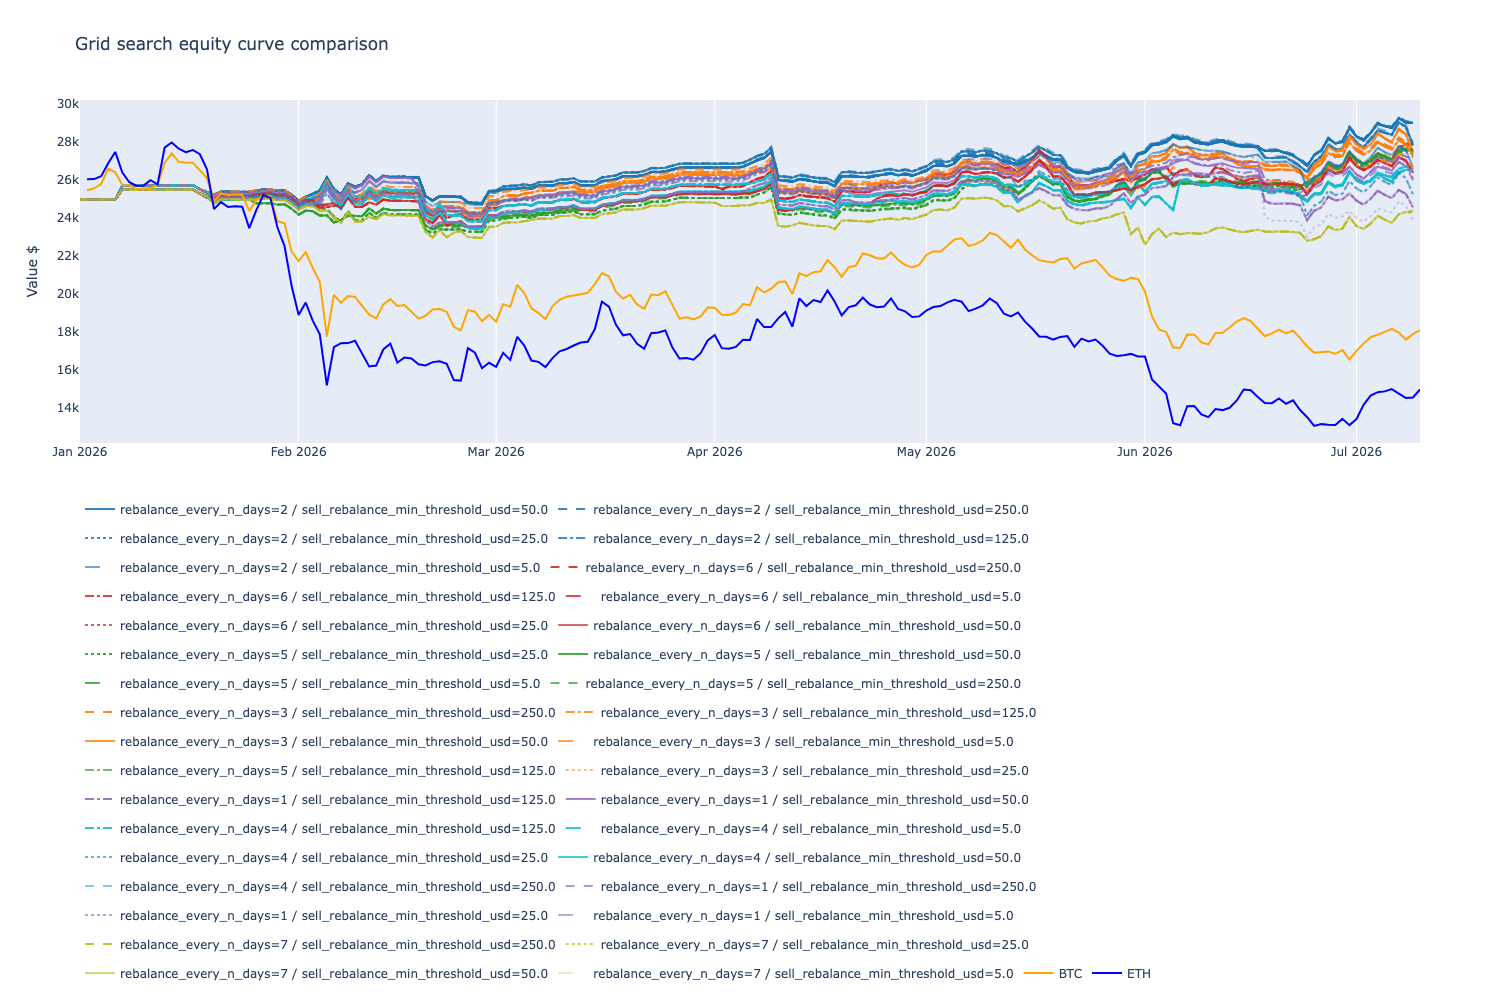

In [12]:
from tradeexecutor.visual.grid_search_basic import visualise_grid_search_equity_curves
from tradeexecutor.analysis.multi_asset_benchmark import get_benchmark_data

# Automatically create BTC and ETH buy and hold benchmark if present
# in the trading universe
benchmark_indexes = get_benchmark_data(
    strategy_universe,
    cumulative_with_initial_cash=Parameters.initial_cash,
    start_at=pd.Timestamp(Parameters.backtest_start),
)

# Extract GridSearchResult instances from optimiser results.
#
# `ignore_wallet_errors=True` turns a crashed backtest into a placeholder GridSearchResult whose
# equity curve is indexed at 1970-01-01/02 (see create_grid_search_failed_result). Those rows are
# not removed by `r.filtered`, which only reflects the MinTradeCountFilter, so leaving them in
# stretches the chart's x axis from 1970 to 2026 and flattens every real curve into a vertical line.
candidates = [r.result for r in optimiser_result.results if not r.filtered]
grid_search_results = [r for r in candidates if r.exception is None]
failed = len(candidates) - len(grid_search_results)
if failed:
    print(f"Excluding {failed} backtest(s) that failed with an exception from the equity curve chart")

fig = visualise_grid_search_equity_curves(
    grid_search_results,
    benchmark_indexes=benchmark_indexes,
    log_y=False,
    group_by="rebalance_every_n_days",
    group_by_secondary="sell_rebalance_min_threshold_usd",
)
fig.show()

# Parameter analysis

## Decision tree visualisation

Analysing Calmar for parameters: ['minimum_hold_days', 'rebalance_every_n_days', 'sell_rebalance_min_threshold_usd']


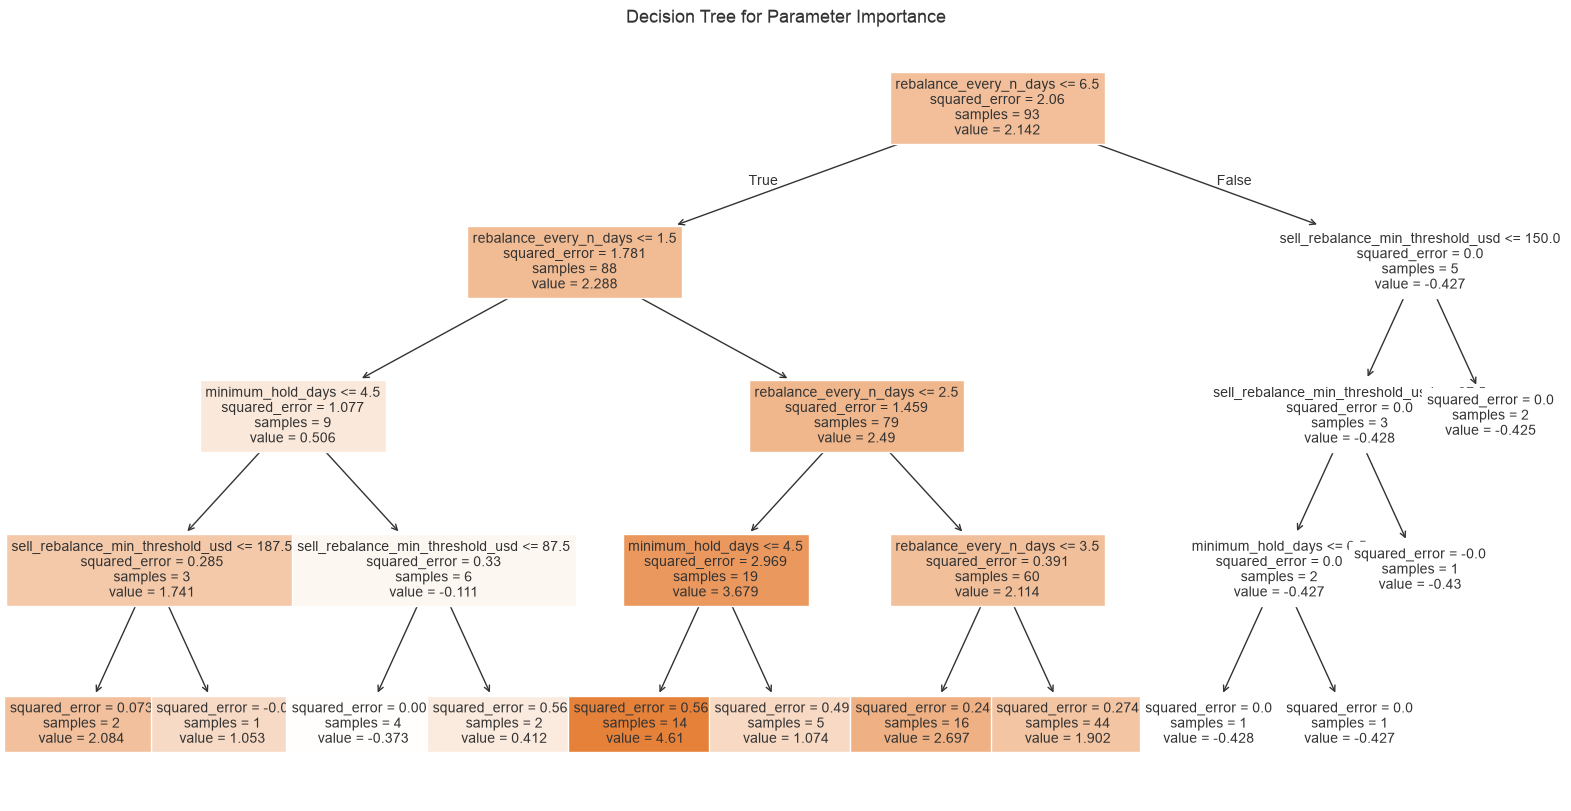

In [13]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree

parameter_names = list(df.index.names)
parameter_df = df
parameter_df = parameter_df.reset_index()

analysis_metric = "Calmar"
print(f"Analysing {analysis_metric} for parameters: {parameter_names}")

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a simple decision tree
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X, y)

# Plot
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=10)
plt.title('Decision Tree for Parameter Importance')
plt.show()

## Feature importance analysis

Use a regression model to determine which parameters have the strongest influence.



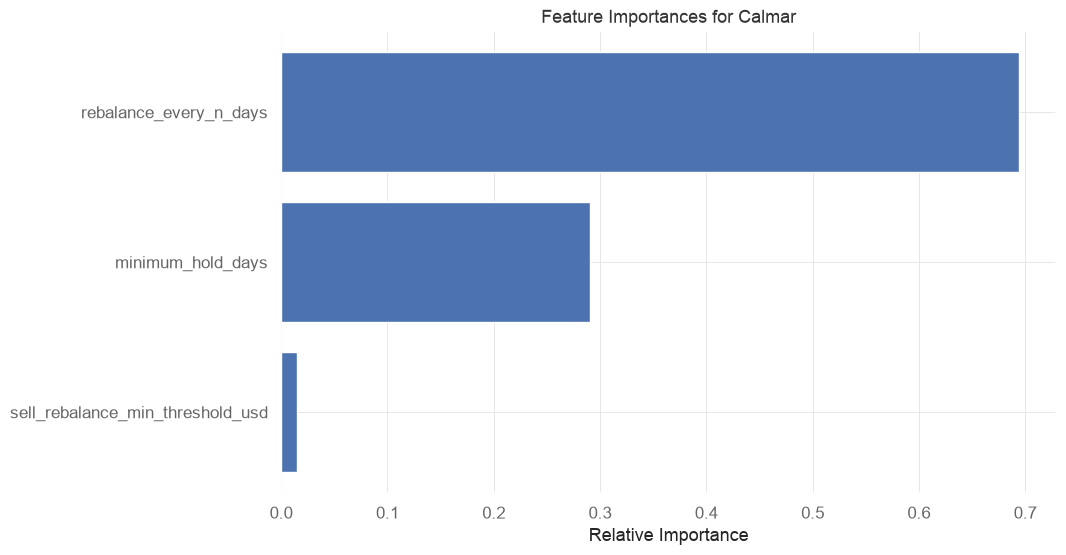

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values to numeric if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a random forest model
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# Plot feature importances
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title(f'Feature Importances for {analysis_metric}')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Heatmaps for parameter pairs

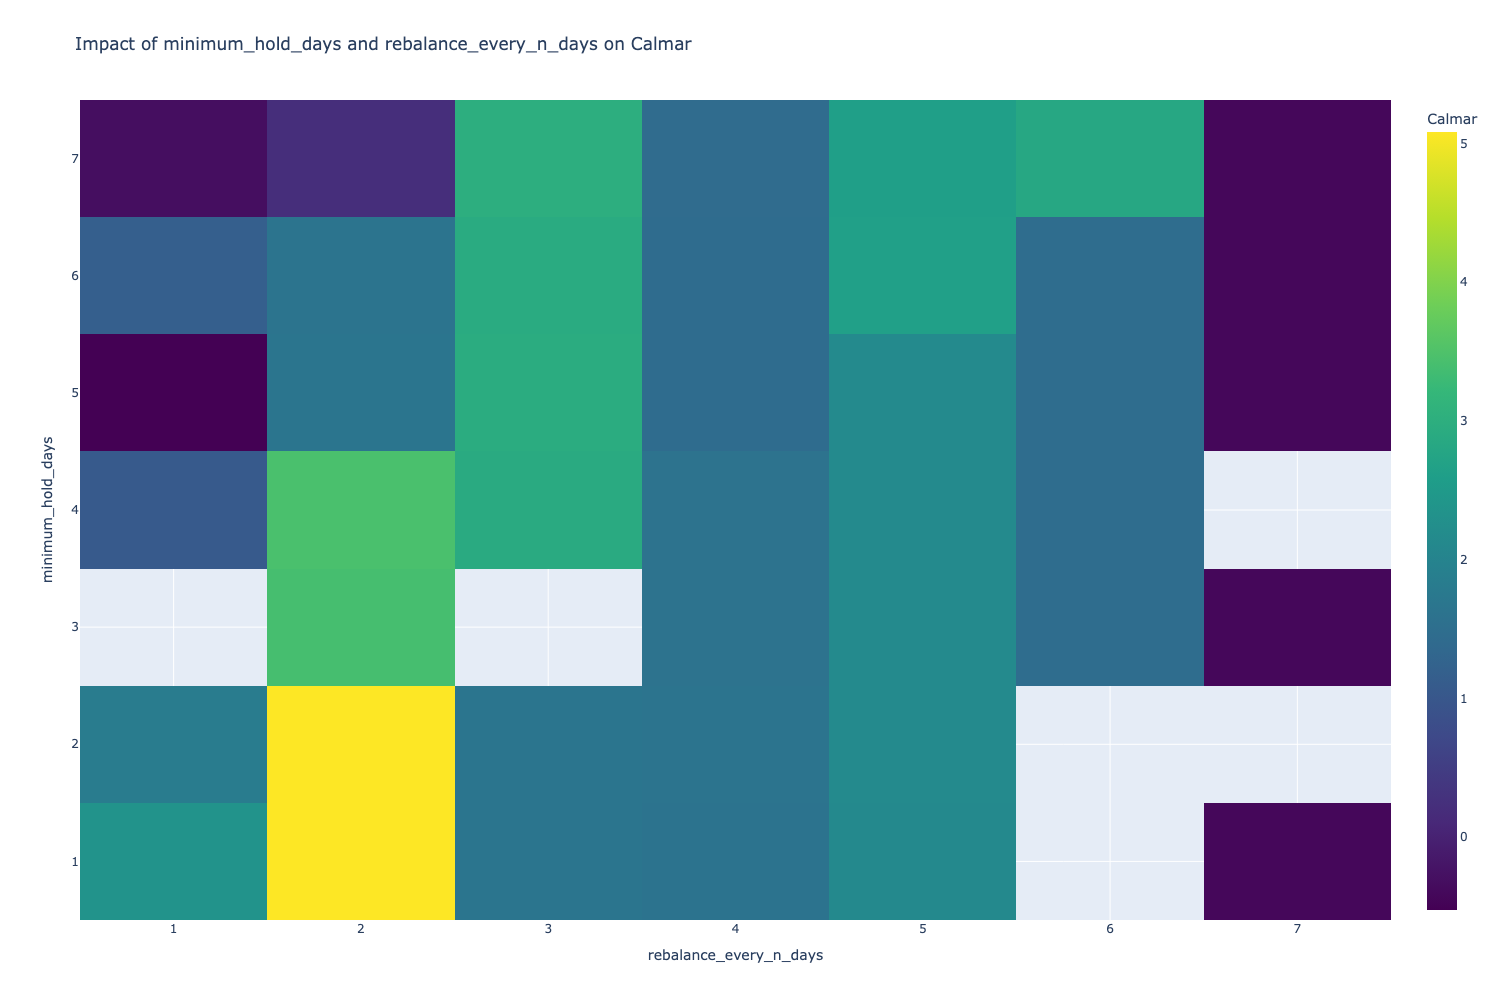

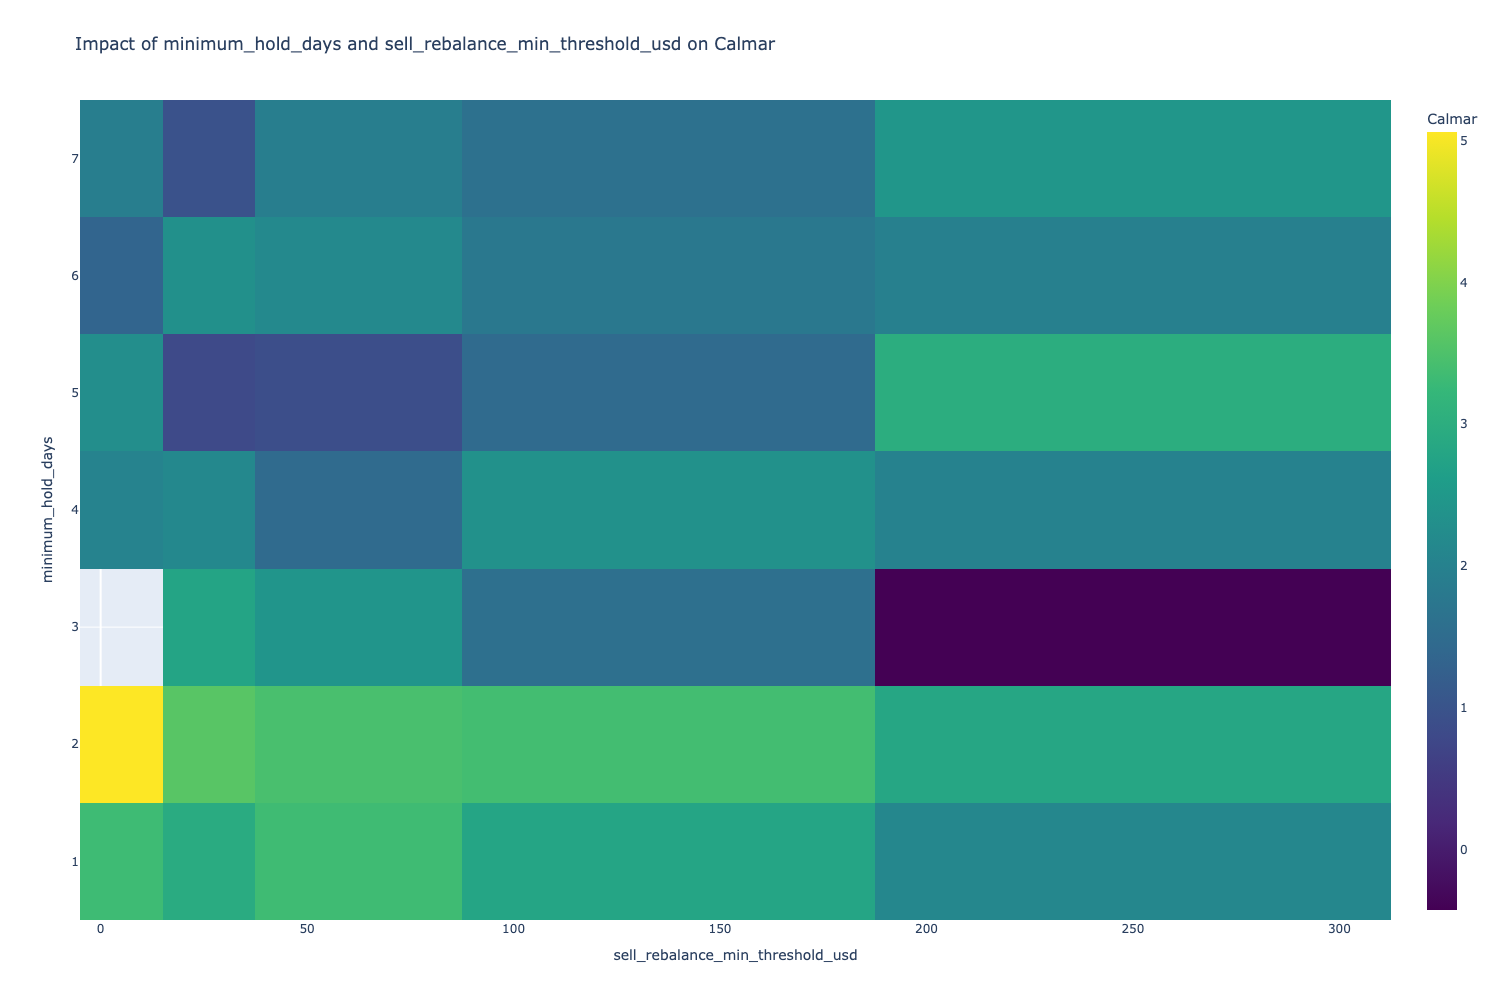

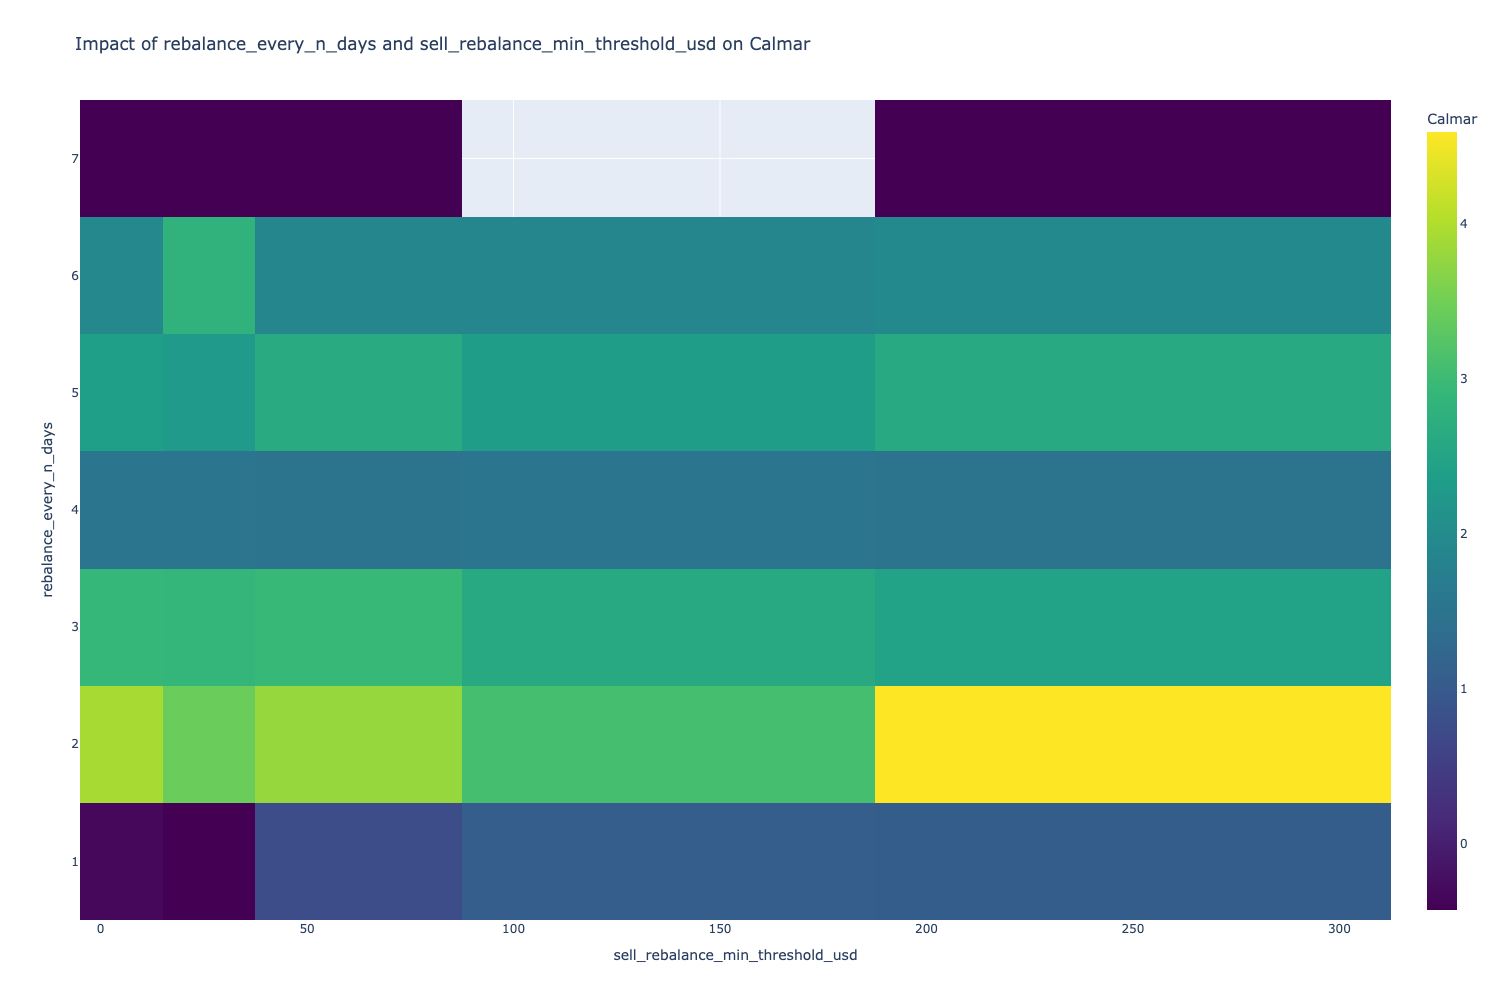

In [15]:
import plotly.graph_objects as go
import numpy as np

def create_heatmap(df, param1, param2, metric):
    # Create pivot table
    pivot = df.pivot_table(
        values=metric, 
        index=param1,
        columns=param2,
        aggfunc="mean"
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Viridis',
        colorbar=dict(title=metric)
    ))
    
    fig.update_layout(
        title=f'Impact of {param1} and {param2} on {metric}',
        xaxis_title=param2,
        yaxis_title=param1
    )
    
    return fig

# All parameter pairs, not just consecutive ones - the consecutive-only loop skipped
# hold x softband entirely.
from itertools import combinations

param_pairs = list(combinations(parameter_names, 2))

for param1, param2 in param_pairs:
    fig = create_heatmap(parameter_df, param1, param2, metric=analysis_metric)
    fig.show()

## Cluster analysis

cluster      CAGR                              Sharpe                      \
               mean       min       max count      mean       min       max   
0       0  0.145852 -0.049203  0.237571    28  0.819710 -0.153357  1.258701   
1       1  0.111352 -0.085726  0.231961    22  0.636801 -0.242243  1.181575   
2       2  0.168514 -0.048570  0.340346    17  0.909166 -0.150296  1.705293   
3       3  0.141295 -0.048570  0.211861    13  0.807336 -0.150296  1.165551   
4       4  0.276549  0.126402  0.336822    13  1.418106  0.705464  1.694004   

     Max DD                      
       mean       min       max  
0 -0.087980 -0.114321 -0.076828  
1 -0.081030 -0.163043 -0.063326  
2 -0.077711 -0.114319 -0.064667  
3 -0.090202 -0.114319 -0.076828  
4 -0.068815 -0.076156 -0.066105

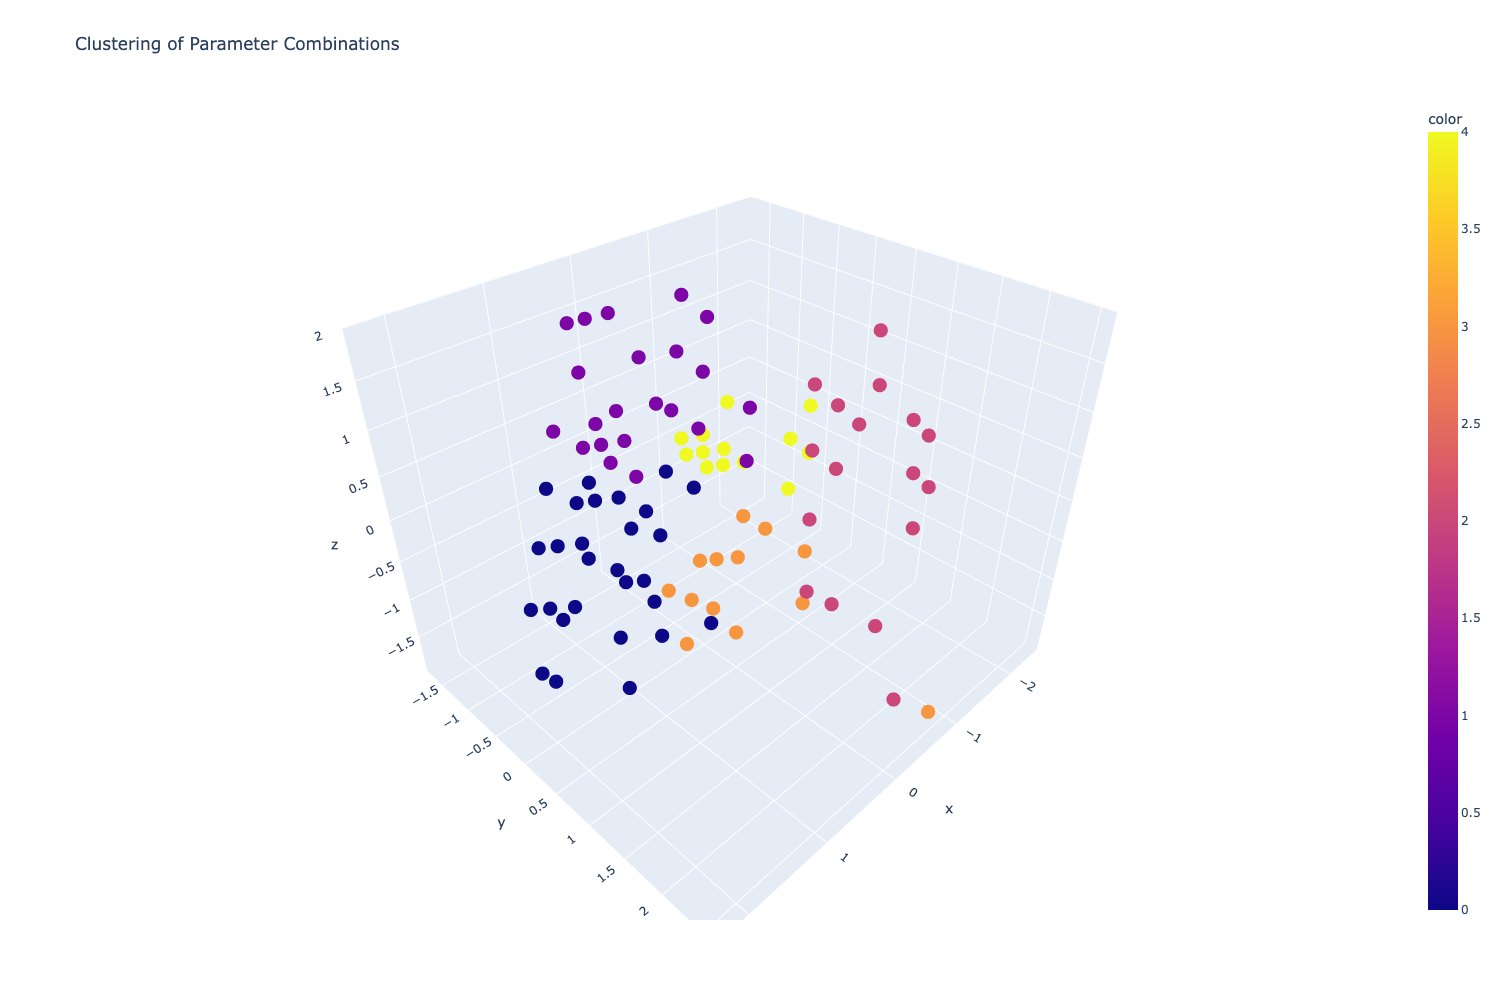

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Select features for clustering
features = parameter_names
X = parameter_df[features]

# Convert categorical values to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering (determine optimal k separately)
kmeans = KMeans(n_clusters=5, random_state=42)
parameter_df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze performance by cluster
cluster_perf = parameter_df.groupby('cluster').agg({
    'CAGR': ['mean', 'min', 'max', 'count'],
    'Sharpe': ['mean', 'min', 'max'],
    'Max DD': ['mean', 'min', 'max']
}).reset_index()

display(cluster_perf)

# Visualize clusters in 3D space (using first 3 PCA components)
from sklearn.decomposition import PCA

try:
    pca = PCA(n_components=3)
    components = pca.fit_transform(X_scaled)

    fig = px.scatter_3d(
        x=components[:, 0],
        y=components[:, 1],
        z=components[:, 2],
        color=parameter_df['cluster'],
        hover_data={'Sharpe': parameter_df['Sharpe'], 'CAGR': parameter_df['CAGR']},
        title='Clustering of Parameter Combinations'
    )
    fig.show()
except ValueError as e:
    print(f"Error in PCA: {e}")
    print("PCA failed, possibly due to too few features or singular matrix.")
    # Handle the error as needed

## Parallel coordinates plot

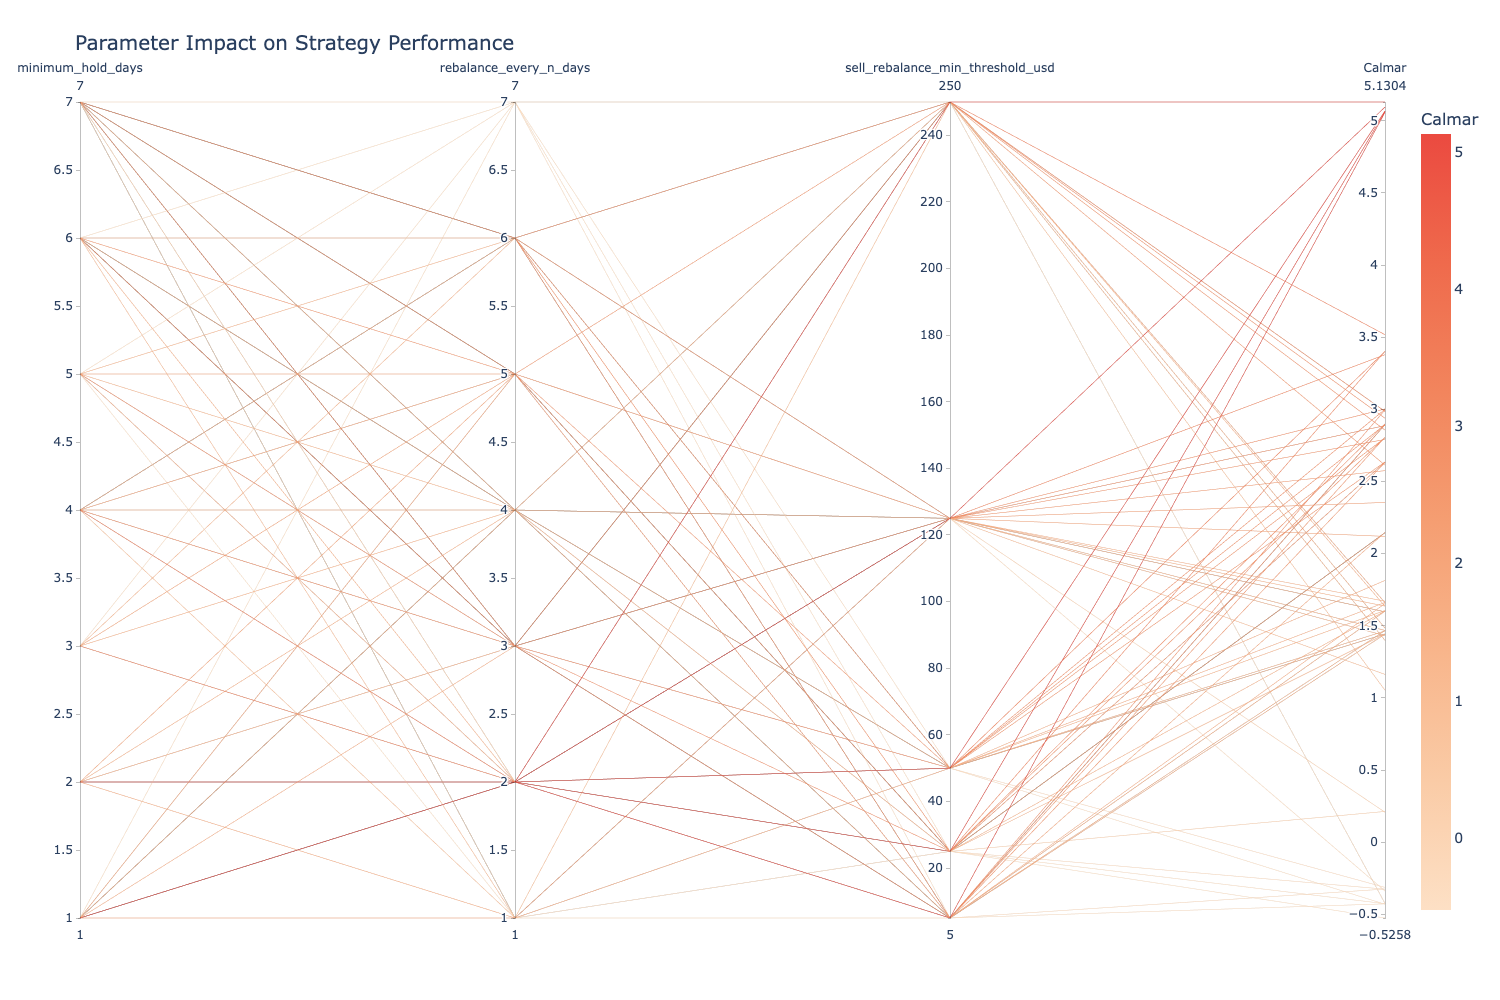

In [17]:
import plotly.express as px

# Extract top results (e.g., top 50)
top_results = parameter_df.head(50)

dimensions = parameter_names + [analysis_metric]

# Create parallel coordinates plot
fig = px.parallel_coordinates(
    parameter_df,
    dimensions=dimensions,
    color=analysis_metric,
    color_continuous_scale=px.colors.sequential.Peach,
    title='Parameter Impact on Strategy Performance'
)


# Increase font size for axis titles, tick labels, and title
fig.update_layout(
    font=dict(size=14),  # Base font size for the whole figure
    title=dict(
        text='Parameter Impact on Strategy Performance',
        font=dict(size=20)  # Title font size
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text=analysis_metric,
            font=dict(size=16)
        ),
        tickfont=dict(size=14)
    )
)

# Parallel coordinates chart: Line width not supported
# https://github.com/plotly/plotly.js/issues/2573

fig.show()

# The best candidate equity curve

The best result found for <function optimise_calmar at 0x12fdd40f0> was <GridSearchResult
  #3, minimum_hold_days=1, rebalance_every_n_days=2, sell_rebalance_min_threshold_usd=50.0
  CAGR: 34.00%, Sharpe: 1.69, Sortino: 2.47, Max drawdown:-7.00%
>


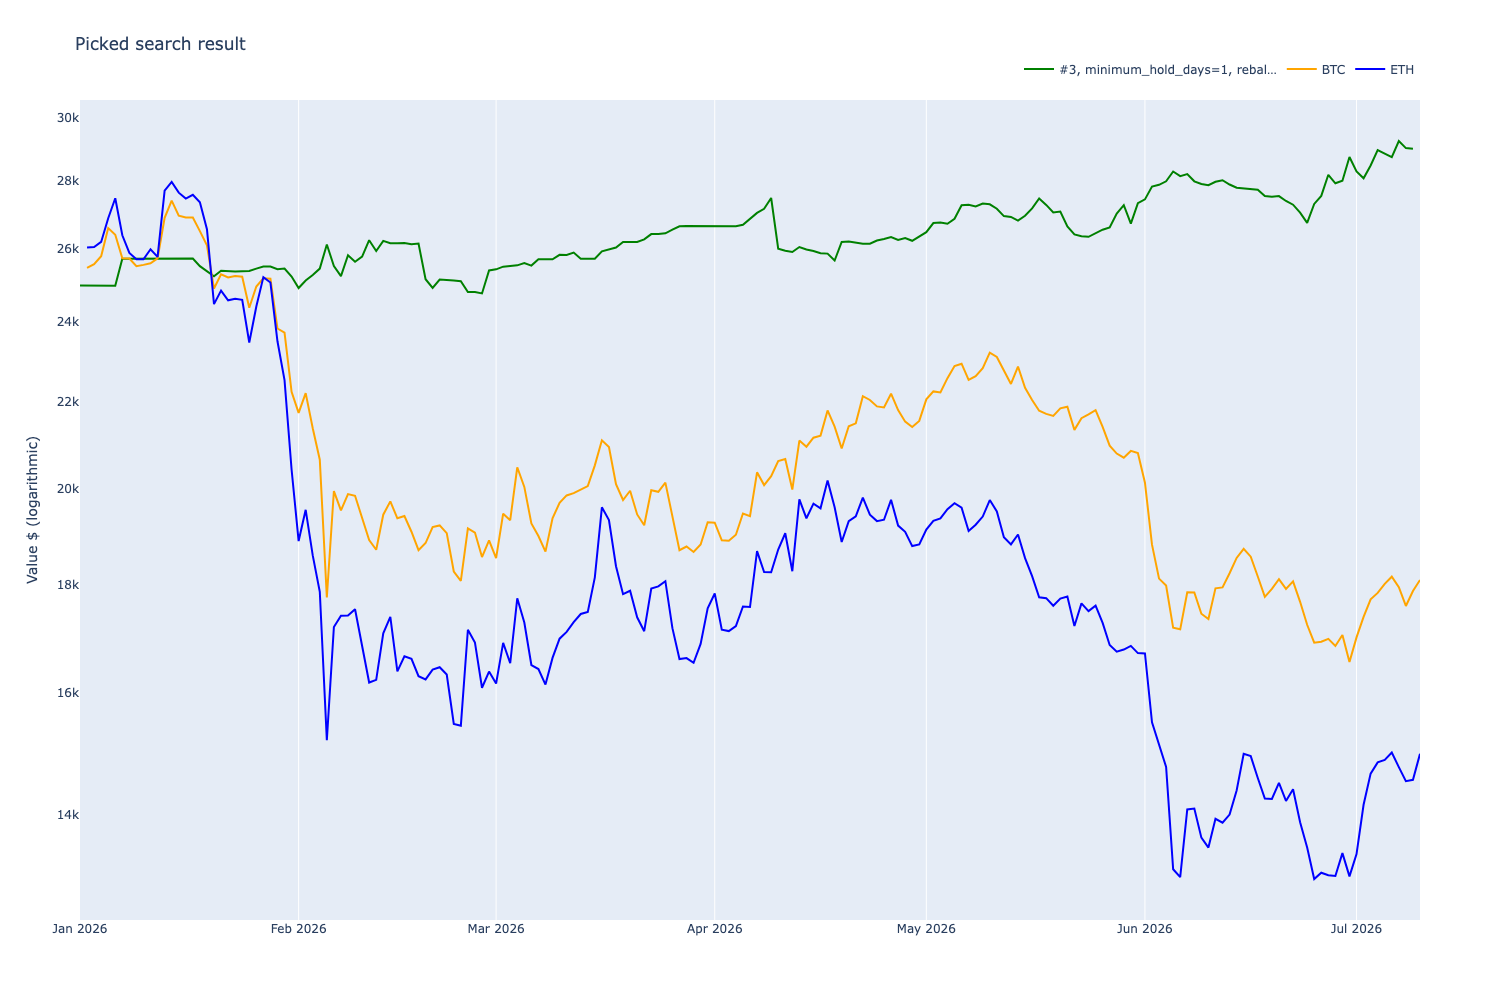

In [18]:
from tradeexecutor.visual.grid_search import visualise_single_grid_search_result_benchmark

# GridSearchResult instance that gave the best performance
best_pick = next(result.result for result in optimiser_result.results if not result.filtered)
state = best_pick.hydrate_state()

print(f"The best result found for {search_func} was {best_pick}")

fig = visualise_single_grid_search_result_benchmark(
    best_pick, 
    strategy_universe, 
    initial_cash=Parameters.initial_cash,
    log_y=True,
)
fig.show()

# Portfolio performance (best pick)

- Compare buy and hold against our best performance

In [19]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

returns = best_pick.returns

df = compare_strategy_backtest_to_multiple_assets(
    state=state,
    strategy_universe=strategy_universe,
    returns=returns,
    display=True,
    asset_count=3,
)
display(df)

,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-09,2026-07-09,2026-07-09
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,94.0%,98.0%,98.0%
Cumulative Return,16.15%,-30.66%,-44.48%
CAGR﹪,33.53%,-50.7%,-67.9%
Sharpe,1.69,-1.2,-1.42
Prob. Sharpe Ratio,87.88%,19.25%,15.41%
Smart Sharpe,1.57,-1.12,-1.32
Sortino,2.47,-1.63,-1.92


# Trade summary (best pick)

- Show statistics about the made trades

In [20]:
summary = best_pick.summary
display(summary.to_dataframe())

,0
Trading period length,188 days 0 hours
Trading start,None
Trading end,None
Return %,16.04%
Annualised return %,31.14%
Cash at start,"$25,000.00"
Value at end,"$29,009.33"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$653,179.75"


# Trading pair performance breakdown

- Show breakdown of different pairs on the best result

In [21]:
from tradeexecutor.analysis.multipair import analyse_multipair
from tradeexecutor.analysis.multipair import format_multipair_summary

multipair_summary = analyse_multipair(state)
display(format_multipair_summary(multipair_summary))

,Trading pair,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
3,Scared Money,7,39,52.86%,795.14,28.65%,-8.09%,7.55%,3.07%,"22,107.76",4,3,0,0,0,11.79%
2,Realist Capital,4,55,50.64%,"2,576.91",39.47%,-6.26%,12.66%,8.71%,"42,310.39",3,1,0,0,0,16.64%
24,HyperProfit {PRO},2,6,25.59%,352.18,23.49%,2.10%,12.80%,12.80%,"6,470.74",2,0,0,0,0,10.70%
0,Goon Edging,4,35,14.18%,"1,570.09",11.90%,-12.11%,3.55%,7.20%,"39,819.27",3,1,0,0,0,9.68%
7,Growi HF,1,4,6.11%,223.79,6.11%,6.11%,6.11%,6.11%,"7,544.96",1,0,0,0,0,0.00%
1,Mad Scientists,1,8,3.72%,232.31,3.72%,3.72%,3.72%,3.72%,"7,877.78",1,0,0,0,0,0.00%
5,pmalt,4,63,3.32%,957.26,4.98%,-2.30%,0.83%,0.32%,"59,209.52",2,2,0,0,0,2.64%
9,Mahamor,2,8,1.86%,69.88,1.96%,-0.10%,0.93%,0.93%,"14,508.41",1,1,0,0,0,1.03%
4,69 Jump Street,4,17,0.46%,55.15,0.85%,-0.52%,0.12%,0.07%,"59,785.32",2,2,0,0,0,0.55%
18,Gucky_1coin_1dot5x,1,35,0.13%,23.93,0.13%,0.13%,0.13%,0.13%,"36,890.36",1,0,0,0,0,0.00%


# Best positions

- Find positions that made most profit for the leading backtest

In [22]:
profit_by_position = [(p.get_realised_profit_usd(), p) for p in state.portfolio.get_all_positions()]
profit_by_position.sort(key=lambda t: t[0] or -999_999_999, reverse=True)

data = []

for profit, p in profit_by_position[0:5]:
    data.append({
        "Profit USD": profit,
        "Pair": p.pair.get_ticker(),
        "Position id": p.position_id,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Duration": p.closed_at - p.opened_at if p.closed_at else "(still open)",
        "Open price": p.get_opening_price(),
        "Close price": p.get_closing_price(),
        "Trades": p.get_trade_count(),
        "Price gain %": (p.get_closing_price() - p.get_opening_price()) / p.get_opening_price() * 100,
        "Weight at open %": p.get_capital_tied_at_open_pct() * 100,
    })

df = pd.DataFrame(data)
display(df)

,Profit USD,Pair,Position id,Opened,Closed,Duration,Open price,Close price,Trades,Price gain %,Weight at open %
0,1202.533624,Realist Ca-USDC,28,2026-03-08,2026-05-31,84 days,3.718453,4.395405,38,18.205207,12.515629
1,1114.178795,Goon Edgin-USDC,45,2026-05-23,2026-06-14,22 days,1.294897,1.572804,12,21.461690,6.936863
2,1011.858095,pmalt-USDC,7,2026-01-05,2026-05-21,136 days,10.323048,11.255627,54,9.033952,5.254185
3,408.104787,Goon Edgin-USDC,16,2026-02-02,2026-02-20,18 days,1.509088,1.746880,10,15.757319,11.164661
4,390.033241,Scared Mon-USDC,38,2026-04-27,2026-05-17,20 days,0.000028,0.000031,10,10.157418,4.158796


# Rolling sharpe

- The rolling sharpe ratio of the best pick

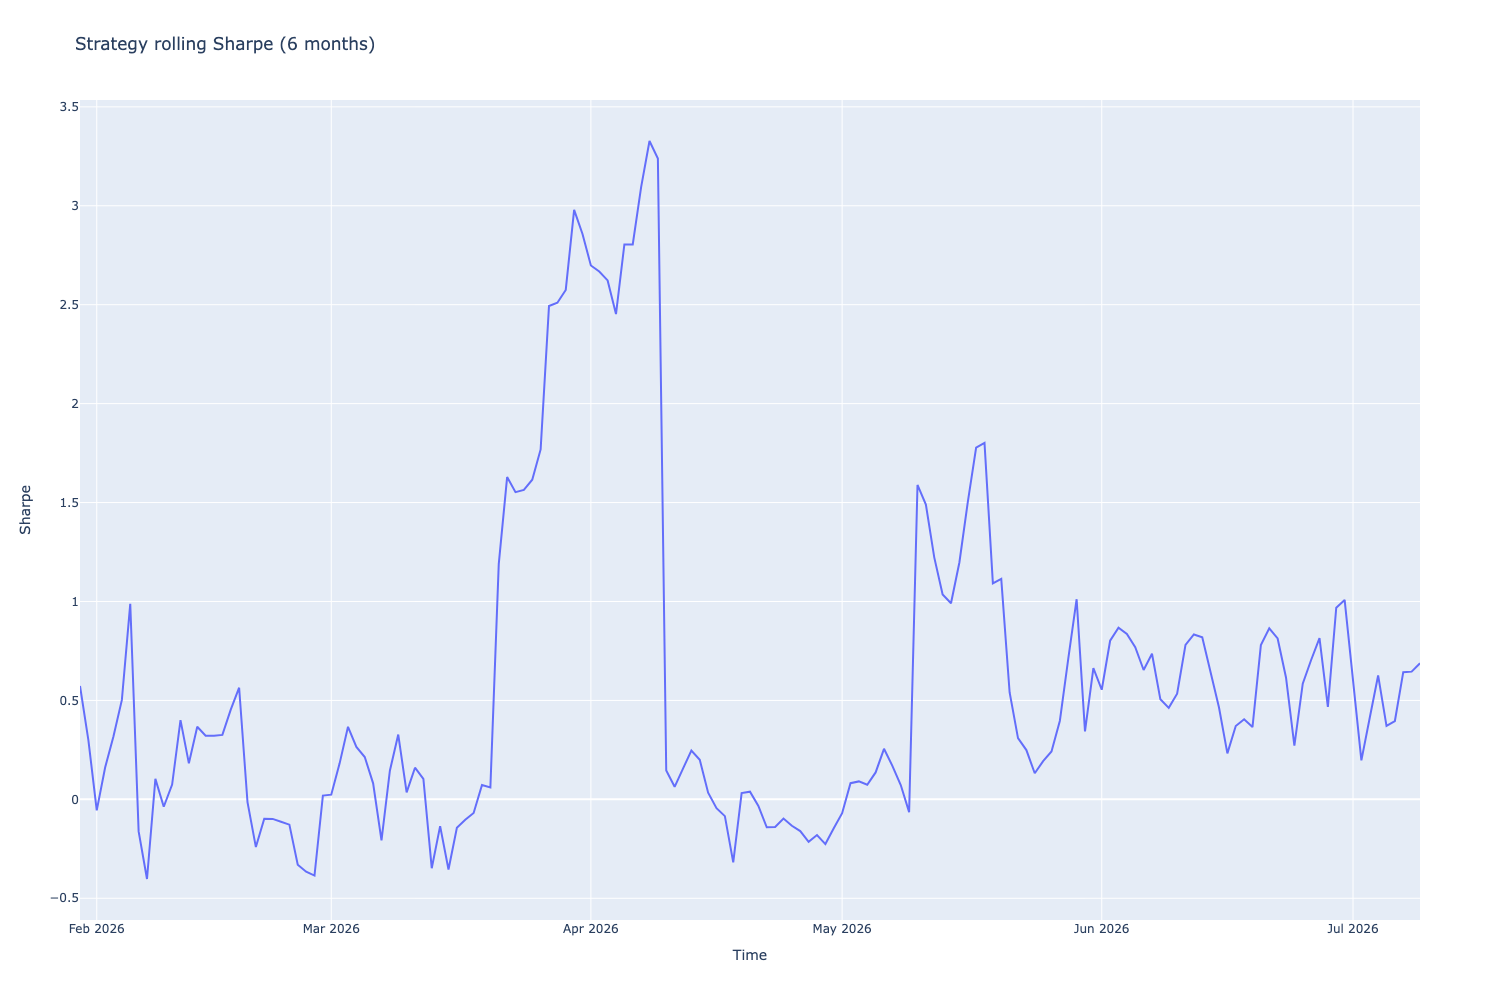

In [23]:
import plotly.express as px

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import calculate_rolling_sharpe

# A 180-day window over a ~190-day backtest leaves ~10 points; 30 days is readable.
rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=30,
)

fig = px.line(rolling_sharpe, title='Strategy rolling Sharpe (6 months)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()

# Data diagnosics

- Some example code to track down issues with data


In [24]:
# data = [{"Timestamp": s.calculated_at, "Equity": s.net_asset_value} for s in state.stats.portfolio]
# df = pd.DataFrame(data)
# df = df.set_index("Timestamp")

# with pd.option_context('display.min_rows', 50, "display.max_rows", 50):
#     display(df)

In [25]:
# for t in state.portfolio.get_all_trades():
#     if t.executed_at.date() == datetime.date(2023, 12, 29):
#         print(t, t.pair, t.get_value())

In [26]:
# import plotly.graph_objects as go

# pair_desc = (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.0005)
# pair = strategy_universe.get_pair_by_human_description(pair_desc)
# df = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)


# fig = go.Figure(data=go.Ohlc(x=df.timestamp,
#                     open=df.open,
#                     high=df.high,
#                     low=df.low,
#                     close=df.close))
# fig.show()

# with pd.option_context('display.min_rows', 5000, "display.max_rows", 5000, 'display.float_format', lambda x: f'{x:.6f}'):
#     display(df)